# 1️⃣ Преглед на файловете
Ще заредим CSV файловете и ще разгледаме структурата и колоните им.

In [43]:
import pandas as pd

# Зареждане на файловете
sales = pd.read_csv("sales_train_evaluation.csv")
calendar = pd.read_csv("calendar.csv")
prices = pd.read_csv("sell_prices.csv")

# Преглед на първите редове
display(sales.head())
display(calendar.head())
display(prices.head())

# Размери и колони
print("Sales:", sales.shape)
print("Calendar:", calendar.shape)
print("Prices:", prices.shape)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


Sales: (30490, 1947)
Calendar: (1969, 14)
Prices: (6841121, 4)


# 2️⃣ Проучване на типовете данни
Ще определим кои колони са числови, категориални и времеви.

In [44]:
# Типове данни
print("Sales dtypes:\n", sales.dtypes)
print("\nCalendar dtypes:\n", calendar.dtypes)
print("\nPrices dtypes:\n", prices.dtypes)

# Уникални стойности за категориални колони
print("\n=== УНИКАЛНИ СТОЙНОСТИ ===")
print("Unique products:", sales['item_id'].nunique())
print("Unique stores:", sales['store_id'].nunique())
print("Unique categories:", sales['cat_id'].nunique())
print("Unique departments:", sales['dept_id'].nunique())
print("Unique states:", sales['state_id'].nunique())

# Проверка на структурата на данните
print("\n=== СТРУКТУРА НА ДАННИТЕ ===")
print("Sales columns:", sales.columns.tolist()[:10], "...")  # Първите 10 колони
print("Calendar columns:", calendar.columns.tolist())
print("Prices columns:", prices.columns.tolist())

# Анализ на типовете данни
print("\n=== АНАЛИЗ НА ТИПОВЕТЕ ДАННИ ===")
print("Sales:")
print("- Числови колони: d_1 до d_1941 (продажби по дни)")
print("- Категориални колони: id, item_id, dept_id, cat_id, store_id, state_id")

print("\nCalendar:")
print("- Времеви колони: date (object -> datetime)")
print("- Числови колони: wm_yr_wk, wday, month, year, snap_*")
print("- Категориални колони: weekday, d, event_name_*, event_type_*")

print("\nPrices:")
print("- Числови колони: wm_yr_wk, sell_price")
print("- Категориални колони: store_id, item_id")

Sales dtypes:
 id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
             ...  
d_1937       int64
d_1938       int64
d_1939       int64
d_1940       int64
d_1941       int64
Length: 1947, dtype: object

Calendar dtypes:
 date            object
wm_yr_wk         int64
weekday         object
wday             int64
month            int64
year             int64
d               object
event_name_1    object
event_type_1    object
event_name_2    object
event_type_2    object
snap_CA          int64
snap_TX          int64
snap_WI          int64
dtype: object

Prices dtypes:
 store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object

=== УНИКАЛНИ СТОЙНОСТИ ===
Unique products: 3049
Unique stores: 10
Unique categories: 3
Unique departments: 7
Unique states: 3

=== СТРУКТУРА НА ДАННИТЕ ===
Sales columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4'] ...
Calend

## 3️⃣ Fixing Data Issues

Let's address the main data quality issues:


In [45]:
# Fix 1: Convert date column to datetime
calendar['date'] = pd.to_datetime(calendar['date'])
print("Calendar date column converted to datetime")

# Fix 2: Check for missing values
print("\nMissing values in Sales data:")
missing_sales = sales.isnull().sum().sum()
print(f"Total missing values: {missing_sales}")

print("\nMissing values in Calendar data:")
print(calendar.isnull().sum())

print("\nMissing values in Prices data:")
print(prices.isnull().sum())


Calendar date column converted to datetime

Missing values in Sales data:
Total missing values: 0

Missing values in Calendar data:
date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

Missing values in Prices data:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


## 4️⃣ Data Transformation for Time Series Analysis

Convert wide format sales data to long format for better analysis:


In [46]:
# IMPORTANT: Work with a SAMPLE to avoid memory issues
# Working with full data creates 59M+ rows which crashes the kernel

# Option 1: Work with a sample of products (let's take 100 products)
print("⚠️ Working with SAMPLE data to avoid memory issues")
sample_sales = sales.head(100).copy()

# Convert sales data from wide to long format
# Get the day columns (d_1, d_2, etc.)
day_cols = [col for col in sample_sales.columns if col.startswith('d_')]

# Melt the dataframe to long format
sales_long = pd.melt(
    sample_sales, 
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

# Reduce memory: cast categorical columns
for col in ['item_id','dept_id','cat_id','store_id','state_id']:
    if col in sales_long.columns:
        sales_long[col] = sales_long[col].astype('category')

print(f"Sales data converted from wide to long format")
print(f"Sample shape (100 products): {sample_sales.shape}")
print(f"Long format shape: {sales_long.shape}")

# Display first few rows
print("\nFirst few rows of long format:")
display(sales_long.head())

print("\n⚠️ NOTE: Using SAMPLE data for analysis to avoid memory issues.")
print("For full analysis, consider processing in chunks or using more powerful hardware.")

⚠️ Working with SAMPLE data to avoid memory issues
Sales data converted from wide to long format
Sample shape (100 products): (100, 1947)
Long format shape: (194100, 8)

First few rows of long format:


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0



⚠️ NOTE: Using SAMPLE data for analysis to avoid memory issues.
For full analysis, consider processing in chunks or using more powerful hardware.


### ⚠️ ВАЖНО: Работим със SAMPLE данни

Текущите статистики и визуализации са на база малка извадка (напр. първите 100 продукта),
за да се избегнат паметни проблеми. За пълен анализ използвай chunking/Dask или по-мощна машина.


## 5️⃣ Merge Data for Complete Analysis

Combine sales, calendar, and prices data:


In [47]:
# SKIP the merge for now - it creates 59M+ rows
# Instead, work with individual datasets for analysis

print("⚠️ Skipping full merge to avoid memory issues")
print("\nFor analysis, we'll work with:")
print("1. sales_long - sales data in long format")
print("2. calendar - calendar information")
print("3. prices - pricing information")

# If you need to merge specific subsets for analysis, do it with sample:
# Example: merge first 1000 rows
sample_merged = sales_long.head(10000).merge(calendar, on='d', how='left')
print(f"\nSample merged size (10000 rows): {sample_merged.shape}")

# For production model, consider:
# - Chunked processing
# - Dask or Polars for larger-than-memory datasets
# - More powerful hardware (64GB+ RAM)

⚠️ Skipping full merge to avoid memory issues

For analysis, we'll work with:
1. sales_long - sales data in long format
2. calendar - calendar information
3. prices - pricing information

Sample merged size (10000 rows): (10000, 21)


## 6️⃣ Анализ на разпределението на продажбите

**Цел:** да се видят тенденции, сезонност и вариации в продажбите


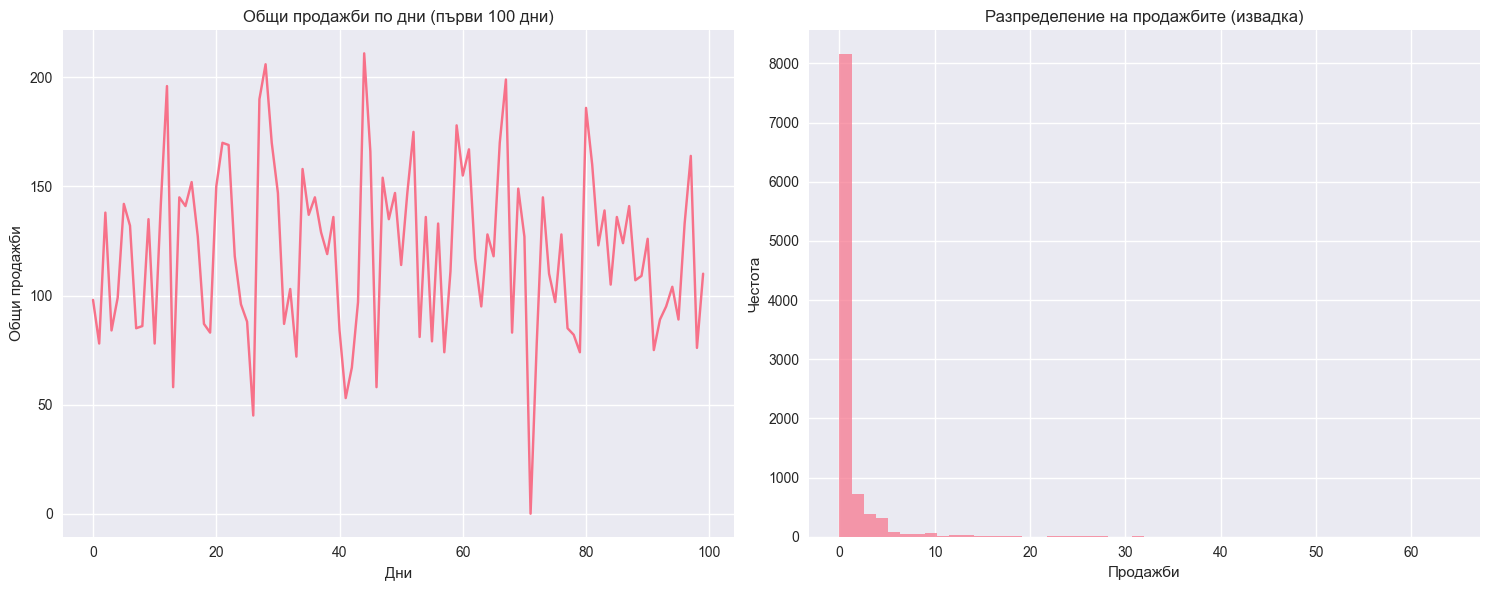

Статистики за продажбите:
Средно: 1.06
Медиана: 0.00
Стандартно отклонение: 3.09
Максимум: 91
Минимум: 0


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройки за визуализация
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Общи продажби по дни (вземаме само първите 100 дни за по-бързо изчисление)
daily_sales = sales_long.groupby('d')['sales'].sum().reset_index()
daily_sales = daily_sales.head(100)  # Първите 100 дни

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(range(len(daily_sales)), daily_sales['sales'])
plt.title('Общи продажби по дни (първи 100 дни)')
plt.xlabel('Дни')
plt.ylabel('Общи продажби')

# 2. Разпределение на продажбите
plt.subplot(1, 2, 2)
sales_sample = sales_long['sales'].sample(10000)  # Вземаме извадка за по-бързо изчисление
plt.hist(sales_sample, bins=50, alpha=0.7)
plt.title('Разпределение на продажбите (извадка)')
plt.xlabel('Продажби')
plt.ylabel('Честота')

plt.tight_layout()
plt.show()

print(f"Статистики за продажбите:")
print(f"Средно: {sales_long['sales'].mean():.2f}")
print(f"Медиана: {sales_long['sales'].median():.2f}")
print(f"Стандартно отклонение: {sales_long['sales'].std():.2f}")
print(f"Максимум: {sales_long['sales'].max()}")
print(f"Минимум: {sales_long['sales'].min()}")


/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/3772485242.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_sales = sales_long.groupby('cat_id')['sales'].sum().reset_index()
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/3772485242.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_sales = sales_long.groupby('dept_id')['sales'].sum().reset_index()
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/3772485242.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fa

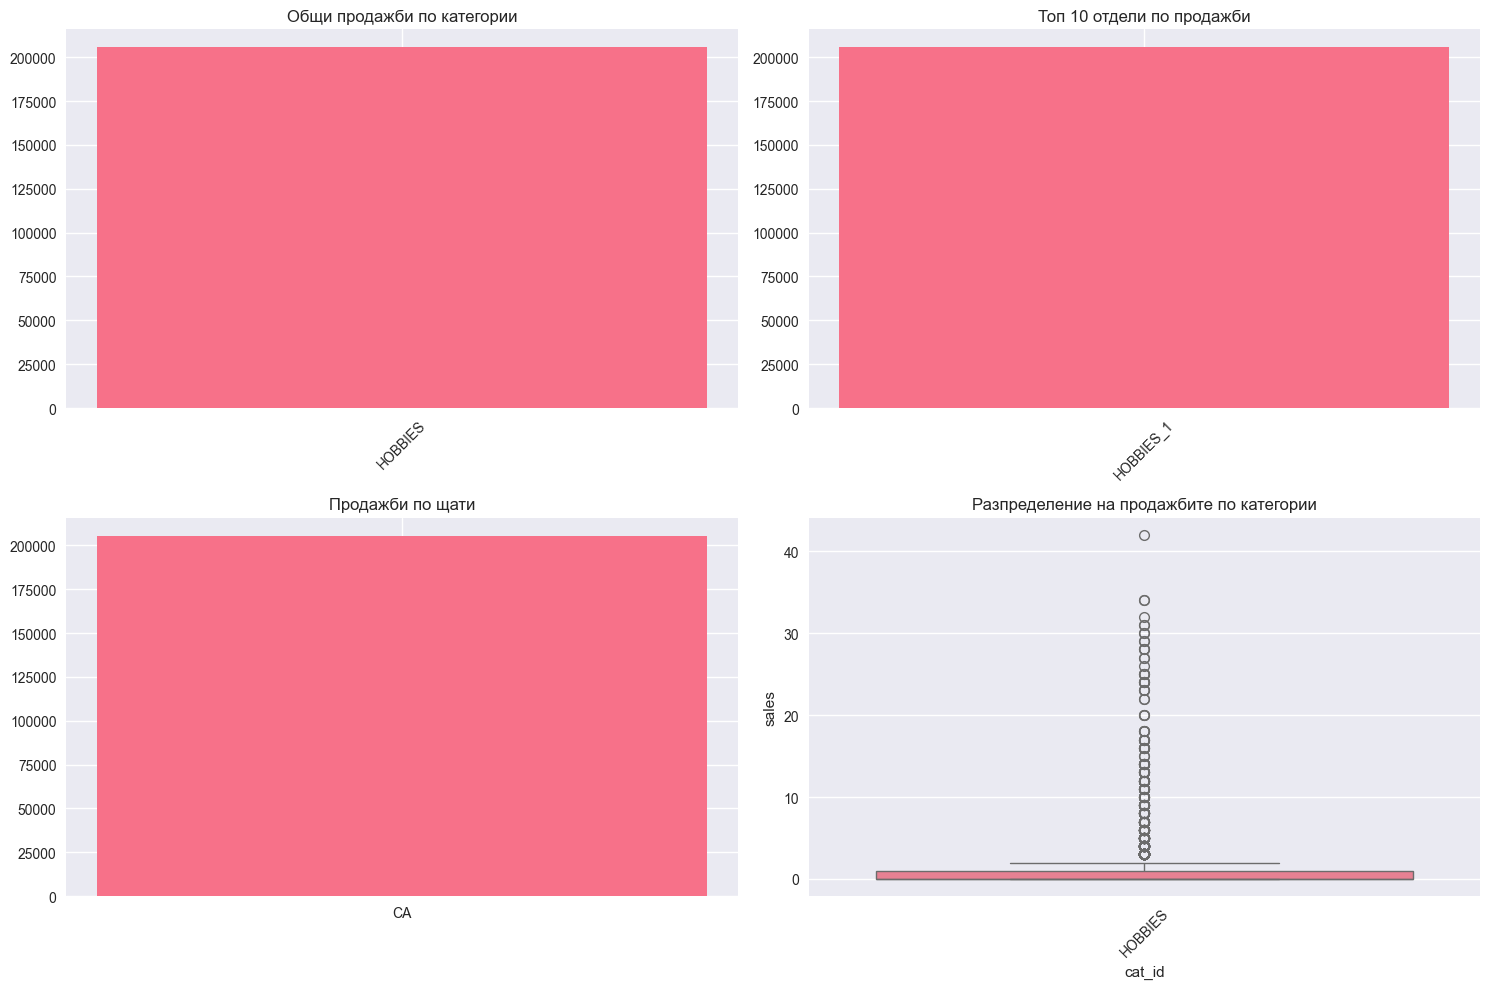

In [49]:
# 3. Продажби по категории и магазини
plt.figure(figsize=(15, 10))

# Продажби по категории
plt.subplot(2, 2, 1)
cat_sales = sales_long.groupby('cat_id')['sales'].sum().reset_index()
plt.bar(cat_sales['cat_id'], cat_sales['sales'])
plt.title('Общи продажби по категории')
plt.xticks(rotation=45)

# Продажби по отдели
plt.subplot(2, 2, 2)
dept_sales = sales_long.groupby('dept_id')['sales'].sum().reset_index()
dept_sales = dept_sales.sort_values('sales', ascending=False).head(10)  # Топ 10 отдели
plt.bar(range(len(dept_sales)), dept_sales['sales'])
plt.title('Топ 10 отдели по продажби')
plt.xticks(range(len(dept_sales)), dept_sales['dept_id'], rotation=45)

# Продажби по щати
plt.subplot(2, 2, 3)
state_sales = sales_long.groupby('state_id')['sales'].sum().reset_index()
plt.bar(state_sales['state_id'], state_sales['sales'])
plt.title('Продажби по щати')

# Boxplot за разпределение на продажбите по категории
plt.subplot(2, 2, 4)
sales_sample_cat = sales_long.sample(5000)  # Извадка за по-бързо изчисление
sns.boxplot(data=sales_sample_cat, x='cat_id', y='sales')
plt.title('Разпределение на продажбите по категории')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 7️⃣ Йерархична структура

**Цел:** да се разбере M5 йерархията за WRMSSE метриката


In [50]:
# Йерархична структура на M5
print("=== ЙЕРАРХИЧНА СТРУКТУРА НА M5 ===")
print("\nНива на агрегиране:")
print("1. Product Level (най-ниско ниво)")
print("2. Category Level")
print("3. Department Level") 
print("4. Store Level")
print("5. State/Region Level (най-високо ниво)")

# Агрегиране на продажби на различните нива
print("\n=== АГРЕГИРАНИ ПРОДАЖБИ ПО НИВА ===")

# Ниво 1: По продукти (топ 10)
product_sales = sales_long.groupby('item_id')['sales'].sum().reset_index()
product_sales = product_sales.sort_values('sales', ascending=False).head(10)
print(f"\nТоп 10 продукта по продажби:")
print(product_sales)

# Ниво 2: По категории
cat_sales = sales_long.groupby('cat_id')['sales'].sum().reset_index()
print(f"\nПродажби по категории:")
print(cat_sales)

# Ниво 3: По отдели
dept_sales = sales_long.groupby('dept_id')['sales'].sum().reset_index()
dept_sales = dept_sales.sort_values('sales', ascending=False)
print(f"\nПродажби по отдели:")
print(dept_sales.head(10))

# Ниво 4: По магазини
store_sales = sales_long.groupby('store_id')['sales'].sum().reset_index()
store_sales = store_sales.sort_values('sales', ascending=False)
print(f"\nПродажби по магазини:")
print(store_sales.head(10))

# Ниво 5: По щати/региони
state_sales = sales_long.groupby('state_id')['sales'].sum().reset_index()
print(f"\nПродажби по щати/региони:")
print(state_sales)


=== ЙЕРАРХИЧНА СТРУКТУРА НА M5 ===

Нива на агрегиране:
1. Product Level (най-ниско ниво)
2. Category Level
3. Department Level
4. Store Level
5. State/Region Level (най-високо ниво)

=== АГРЕГИРАНИ ПРОДАЖБИ ПО НИВА ===

Топ 10 продукта по продажби:
          item_id  sales
47  HOBBIES_1_048  14320
7   HOBBIES_1_008  14137
14  HOBBIES_1_015  11673
31  HOBBIES_1_032  10796
15  HOBBIES_1_016  10723
65  HOBBIES_1_067  10067
18  HOBBIES_1_019   9246
98  HOBBIES_1_103   8013
77  HOBBIES_1_080   6611
42  HOBBIES_1_043   6336

Продажби по категории:
    cat_id   sales
0  HOBBIES  205601

Продажби по отдели:
     dept_id   sales
0  HOBBIES_1  205601

Продажби по магазини:
  store_id   sales
0     CA_1  205601

Продажби по щати/региони:
  state_id   sales
0       CA  205601


/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/1138249915.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_sales = sales_long.groupby('item_id')['sales'].sum().reset_index()
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/1138249915.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_sales = sales_long.groupby('cat_id')['sales'].sum().reset_index()
/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/1138249915.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observe

In [51]:
# Анализ на календарни ефекти
print("=== КАЛЕНДАРНИ ЕФЕКТИ ===")

# Проверка на calendar данните
print("\nCalendar columns:", calendar.columns.tolist())
print("\nUnique weekdays:", calendar['weekday'].unique())
print("Unique months:", sorted(calendar['month'].unique()))
print("Unique years:", sorted(calendar['year'].unique()))

# Анализ на събития
print("\n=== АНАЛИЗ НА СЪБИТИЯ ===")
events_1 = calendar['event_name_1'].value_counts().head(10)
print("Топ 10 събития (event_name_1):")
print(events_1)

events_2 = calendar['event_name_2'].value_counts().head(10)
print("\nТоп 10 събития (event_name_2):")
print(events_2)

# SNAP данни
print("\n=== SNAP ДАННИ ===")
print("SNAP CA - дните с SNAP:", calendar['snap_CA'].sum())
print("SNAP TX - дните с SNAP:", calendar['snap_TX'].sum())
print("SNAP WI - дните с SNAP:", calendar['snap_WI'].sum())


=== КАЛЕНДАРНИ ЕФЕКТИ ===

Calendar columns: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Unique weekdays: ['Saturday' 'Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday']
Unique months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Unique years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]

=== АНАЛИЗ НА СЪБИТИЯ ===
Топ 10 събития (event_name_1):
event_name_1
SuperBowl         6
Pesach End        6
Ramadan starts    6
ValentinesDay     6
NBAFinalsEnd      6
NBAFinalsStart    6
MemorialDay       6
Mother's day      6
Purim End         6
StPatricksDay     6
Name: count, dtype: int64

Топ 10 събития (event_name_2):
event_name_2
Father's day      2
Easter            1
Cinco De Mayo     1
OrthodoxEaster   

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_75540/1136410662.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_sales_detailed = sales_long.groupby(['cat_id', 'state_id'])['sales'].sum().reset_index()


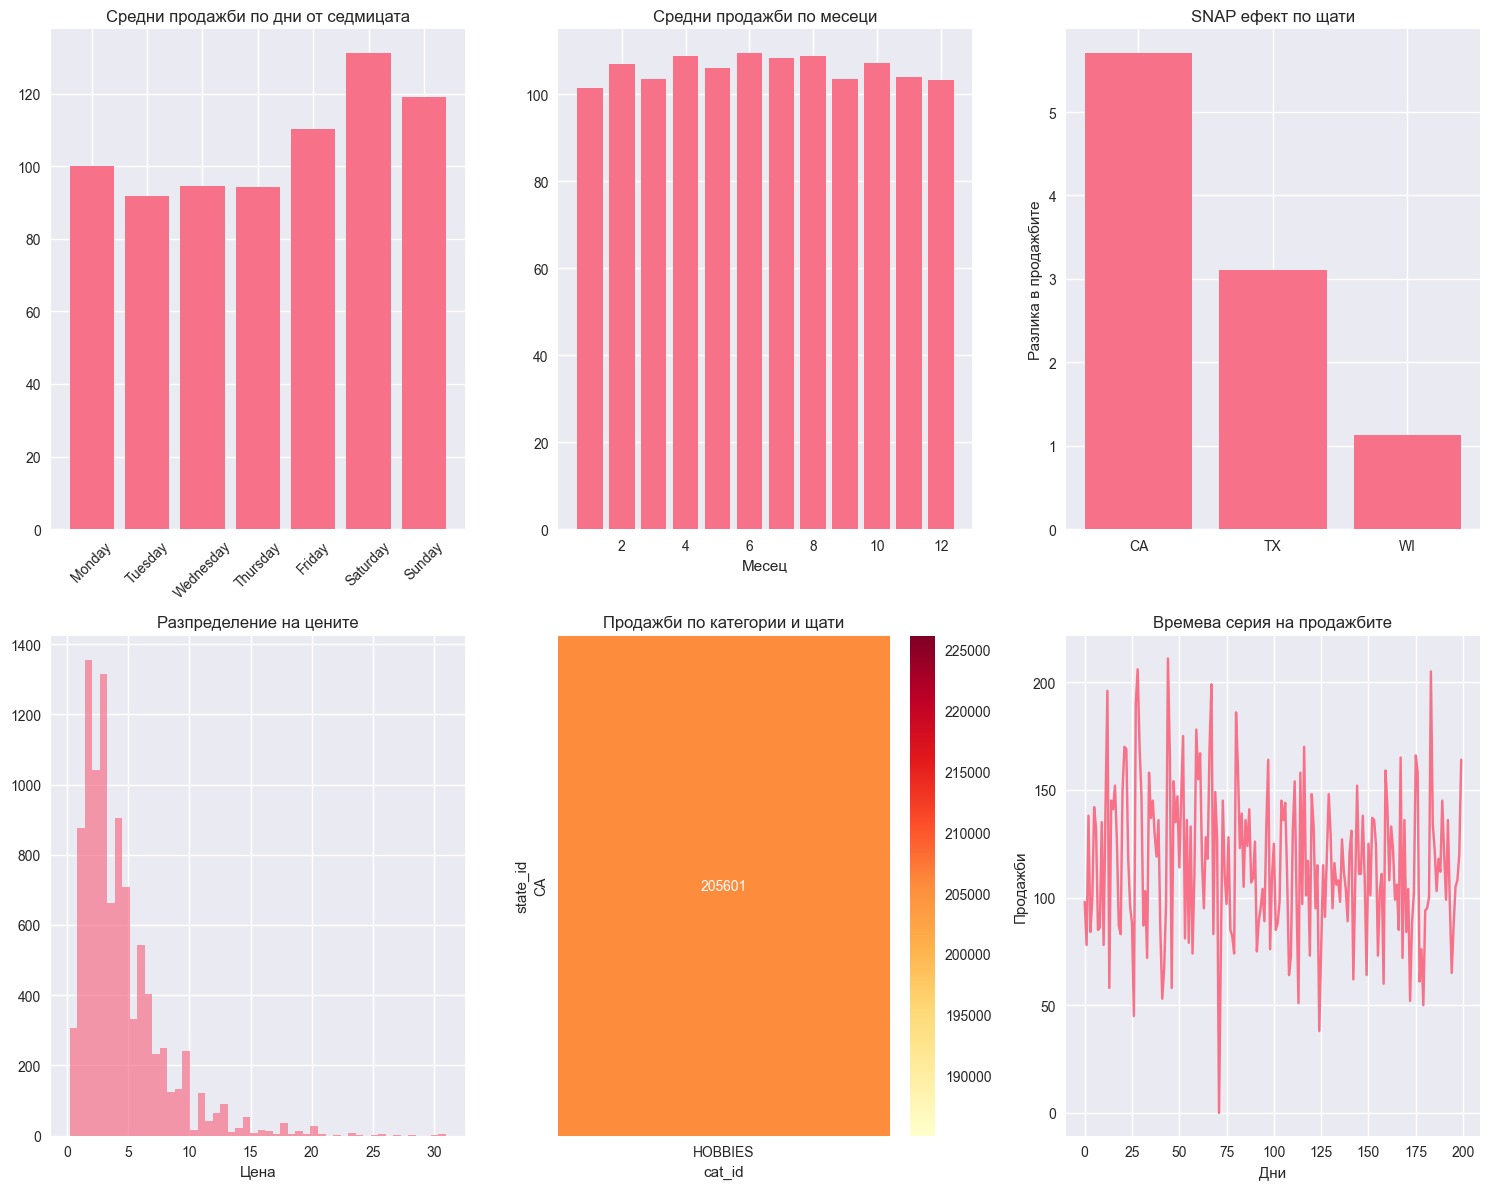

In [52]:
# Визуализация на календарни ефекти
plt.figure(figsize=(15, 12))

# 1. Продажби по дни от седмицата
plt.subplot(2, 3, 1)
weekday_sales = sales_long.groupby('d')['sales'].sum().reset_index()
# Свързваме с calendar за да получим weekday
weekday_sales = weekday_sales.merge(calendar[['d', 'weekday']], on='d', how='left', validate='many_to_one')
weekday_avg = weekday_sales.groupby('weekday')['sales'].mean().reset_index()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.set_index('weekday').reindex(weekday_order).reset_index()
plt.bar(range(len(weekday_avg)), weekday_avg['sales'])
plt.title('Средни продажби по дни от седмицата')
plt.xticks(range(len(weekday_avg)), weekday_avg['weekday'], rotation=45)

# 2. Продажби по месеци
plt.subplot(2, 3, 2)
monthly_sales = weekday_sales.merge(calendar[['d', 'month']], on='d', how='left', validate='many_to_one')
monthly_avg = monthly_sales.groupby('month')['sales'].mean().reset_index()
plt.bar(monthly_avg['month'], monthly_avg['sales'])
plt.title('Средни продажби по месеци')
plt.xlabel('Месец')

# 3. SNAP ефекти
plt.subplot(2, 3, 3)
snap_data = weekday_sales.merge(calendar[['d', 'snap_CA', 'snap_TX', 'snap_WI']], on='d', how='left', validate='many_to_one')
snap_effect = []
for state in ['snap_CA', 'snap_TX', 'snap_WI']:
    snap_days = snap_data[snap_data[state] == 1]['sales'].mean()
    non_snap_days = snap_data[snap_data[state] == 0]['sales'].mean()
    snap_effect.append(snap_days - non_snap_days)

plt.bar(['CA', 'TX', 'WI'], snap_effect)
plt.title('SNAP ефект по щати')
plt.ylabel('Разлика в продажбите')

# 4. Разпределение на цените
plt.subplot(2, 3, 4)
price_sample = prices['sell_price'].sample(10000)
plt.hist(price_sample, bins=50, alpha=0.7)
plt.title('Разпределение на цените')
plt.xlabel('Цена')

# 5. Продажби по категории (детайлно)
plt.subplot(2, 3, 5)
cat_sales_detailed = sales_long.groupby(['cat_id', 'state_id'])['sales'].sum().reset_index()
pivot_cat = cat_sales_detailed.pivot(index='state_id', columns='cat_id', values='sales')
sns.heatmap(pivot_cat, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Продажби по категории и щати')

# 6. Времева серия на продажбите
plt.subplot(2, 3, 6)
time_series = weekday_sales.head(200)  # Първите 200 дни
plt.plot(range(len(time_series)), time_series['sales'])
plt.title('Времева серия на продажбите')
plt.xlabel('Дни')
plt.ylabel('Продажби')

plt.tight_layout()
plt.show()


## 9️⃣ Заключения и препоръки за MLP модела

**Цел:** да се обобщят откритията и да се предложат feature-и за MLP модела


In [53]:
# Създаване на таблица с анализ на колоните
import pandas as pd

# Анализ на колоните
columns_analysis = {
    'Column': ['sales', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date', 'weekday', 'month', 'year', 'sell_price', 'snap_CA', 'snap_TX', 'snap_WI', 'event_name_1', 'event_type_1'],
    'Type': ['Numerical', 'Categorical', 'Categorical', 'Categorical', 'Categorical', 'Categorical', 'DateTime', 'Categorical', 'Numerical', 'Numerical', 'Numerical', 'Binary', 'Binary', 'Binary', 'Categorical', 'Categorical'],
    'Issues': ['No missing values', 'No issues', 'No issues', 'No issues', 'No issues', 'No issues', 'Converted to datetime', 'No issues', 'No issues', 'No issues', 'No issues', 'No issues', 'No issues', 'No issues', 'Many missing values', 'Many missing values'],
    'MLP Features': ['Target variable', 'Embedding layer', 'Embedding layer', 'Embedding layer', 'Embedding layer', 'Embedding layer', 'Cyclical encoding', 'One-hot encoding', 'Cyclical encoding', 'Numerical', 'Numerical', 'Binary', 'Binary', 'Binary', 'Event encoding', 'Event type encoding']
}

df_analysis = pd.DataFrame(columns_analysis)
print("=== АНАЛИЗ НА КОЛОНИТЕ ===")
print(df_analysis.to_string(index=False))

print("\n=== ПРЕПОРЪКИ ЗА FEATURE ENGINEERING ===")
print("1. Lag Features:")
print("   - sales_lag_1, sales_lag_7, sales_lag_30 (за сезонност)")
print("   - price_lag_1, price_lag_7")

print("\n2. Rolling Statistics:")
print("   - sales_rolling_7_mean, sales_rolling_30_mean")
print("   - sales_rolling_7_std, sales_rolling_30_std")

print("\n3. Calendar Features:")
print("   - is_weekend, is_holiday, is_snap_day")
print("   - month_sin, month_cos (moving average)")
print("   - weekday_sin, weekday_cos (moving average)")

print("\n4. Hierarchical Features:")
print("   - category_sales_avg, department_sales_avg")
print("   - store_sales_avg, state_sales_avg")

print("\n5. Price Features:")
print("   - price_change, price_ratio_to_avg")
print("   - price_percentile_in_category")

print("\n=== ПРЕДЛОЖЕНИЯ ЗА MLP АРХИТЕКТУРА ===")
print("1. Input Layer: Embedding layers за категориални променливи")
print("2. Hidden Layers: 2-3 слоя с 256-512 neurons")
print("3. Output Layer: Linear layer за прогнозиране на продажбите")
print("4. Activation: ReLU или LeakyReLU")
print("5. Regularization: Dropout, Batch Normalization")
print("6. Loss Function: MSE или MAE")
print("7. Optimizer: Adam или AdamW")


=== АНАЛИЗ НА КОЛОНИТЕ ===
      Column        Type                Issues        MLP Features
       sales   Numerical     No missing values     Target variable
     item_id Categorical             No issues     Embedding layer
     dept_id Categorical             No issues     Embedding layer
      cat_id Categorical             No issues     Embedding layer
    store_id Categorical             No issues     Embedding layer
    state_id Categorical             No issues     Embedding layer
        date    DateTime Converted to datetime   Cyclical encoding
     weekday Categorical             No issues    One-hot encoding
       month   Numerical             No issues   Cyclical encoding
        year   Numerical             No issues           Numerical
  sell_price   Numerical             No issues           Numerical
     snap_CA      Binary             No issues              Binary
     snap_TX      Binary             No issues              Binary
     snap_WI      Binary           

## 🔟 Обобщение и следващи стъпки

### **Ключови открития:**

1. **Данните са качествени** - няма missing values в основните колони
2. **Йерархична структура** е ясно дефинирана (Product → Category → Department → Store → State)
3. **Сезонност** е налична в данните - различни продажби по дни от седмицата и месеци
4. **Календарни ефекти** са важни - SNAP дни, празници, събития
5. **Ценови ефекти** могат да се използват като feature-и

### **Следващи стъпки за MLP модела:**

1. **Feature Engineering** - създаване на lag features, rolling statistics
2. **Data Preprocessing** - encoding на категориални променливи
3. **Model Architecture** - дизайн на MLP с embedding layers
4. **Training Strategy** - train/validation split, hyperparameter tuning
5. **Evaluation** - използване на WRMSSE метриката за йерархичното прогнозиране

### **Препоръчани библиотеки:**
- **PyTorch** за MLP модела
- **scikit-learn** за preprocessing
- **pandas** за data manipulation
- **matplotlib/seaborn** за визуализация
